# Downloading dataset

In [1]:
import kagglehub
data_path = kagglehub.dataset_download('alincijov/self-driving-cars')
print(data_path)

/kaggle/input/self-driving-cars


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 30.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

# Importing libraries

In [3]:
import numpy as np
import pandas as pd
import cv2
from sklearn.utils import shuffle
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Loading and shuffling data

This dataset is mostly used for training traffic classification but here we use it for pedestrian detection i.e. class==3 as mentioned in the dataset.

In [4]:
df = pd.read_csv(f'{data_path}/labels_train.csv')
df = shuffle(df)
peds_df = df[df['class_id'] == 3]
peds_df.head(10)

,frame,xmin,xmax,ymin,ymax,class_id
121658,1479505276933194104.jpg,143,160,136,166,3
99036,1479503084283705674.jpg,72,81,137,163,3
57343,1478898367444503552.jpg,224,232,155,172,3
114246,1479504697892231795.jpg,410,433,120,192,3
115579,1479504799401432894.jpg,84,95,135,166,3
56341,1478898334309957386.jpg,241,251,147,166,3
81042,1479500771127612504.jpg,358,366,148,156,3
53633,1478898137215242925.jpg,64,73,148,178,3
72954,1479499835564629242.jpg,252,261,139,148,3
60407,1478898646804541349.jpg,249,258,151,164,3


In [5]:
print(f"Total entries found: {len(peds_df)}")

Total entries found: 10637


Labeled images

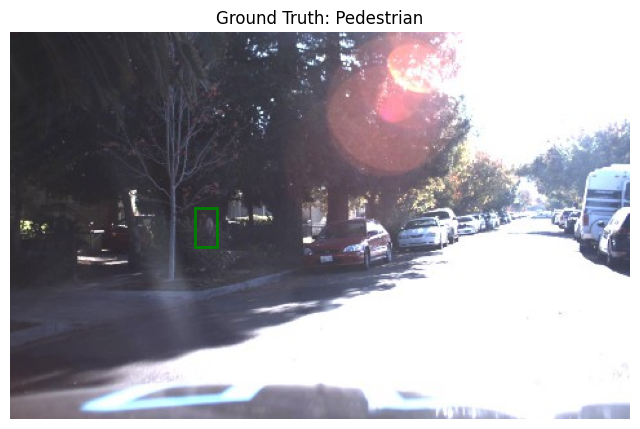

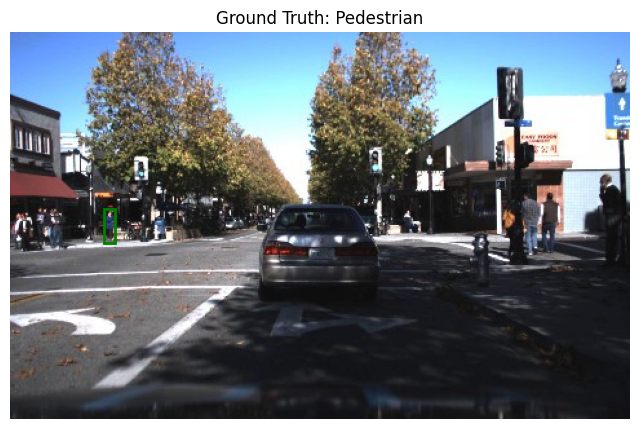

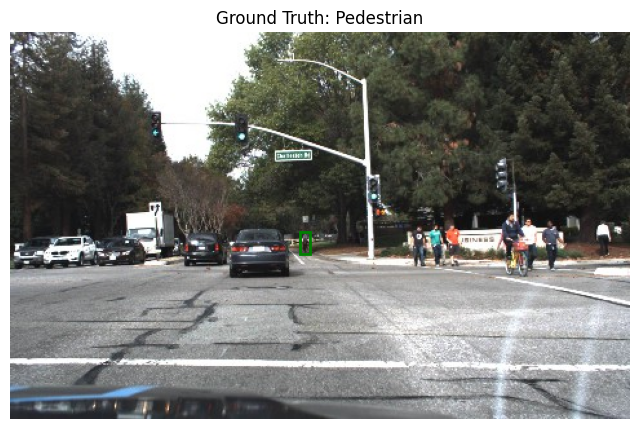

In [6]:
for i in range(3):
    row = peds_df.iloc[i]
    image_path = f"{data_path}/images/{row['frame']}"
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    xmin, xmax = int(row['xmin']), int(row['xmax'])
    ymin, ymax = int(row['ymin']), int(row['ymax'])

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    ax.set_title("Ground Truth: Pedestrian")
    plt.axis('off')
    plt.show()

# Model

In [7]:
print("Loading YOLOv8 model...")
model = YOLO("yolov8m.pt")

Loading YOLOv8 model...


100%|██████████| 49.7M/49.7M [00:00<00:00, 262MB/s]


YOLO Prediction on same pedestrian images

In [8]:
def detect_peds(image_path):
    results = model.predict(source=image_path, conf=0.2, iou=0.5, save=False)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for r in results:
        for box in r.boxes:
            if box.cls[0].item() != 0:
                continue
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = round(box.conf[0].item(), 2)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, f"person {conf}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    display(Image.fromarray(img))

Pedestrian Detection - Image 1

image 1/1 /kaggle/input/self-driving-cars/images/1479505276933194104.jpg: 416x640 14 cars, 1 bus, 1 truck, 108.1ms
Speed: 10.2ms preprocess, 108.1ms inference, 600.2ms postprocess per image at shape (1, 3, 416, 640)


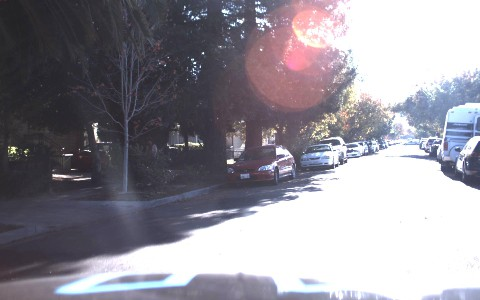

Pedestrian Detection - Image 2

image 1/1 /kaggle/input/self-driving-cars/images/1479503084283705674.jpg: 416x640 12 persons, 3 cars, 4 traffic lights, 1 fire hydrant, 27.8ms
Speed: 3.6ms preprocess, 27.8ms inference, 2.7ms postprocess per image at shape (1, 3, 416, 640)


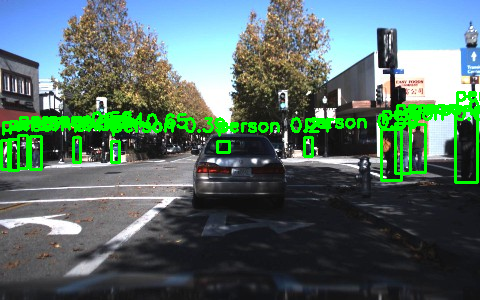

Pedestrian Detection - Image 3

image 1/1 /kaggle/input/self-driving-cars/images/1478898367444503552.jpg: 416x640 8 persons, 1 bicycle, 5 cars, 1 truck, 4 traffic lights, 38.8ms
Speed: 13.0ms preprocess, 38.8ms inference, 2.4ms postprocess per image at shape (1, 3, 416, 640)


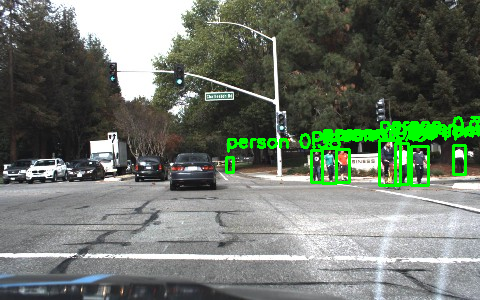

Pedestrian Detection - Image 4

image 1/1 /kaggle/input/self-driving-cars/images/1479504697892231795.jpg: 416x640 12 persons, 1 car, 2 traffic lights, 27.4ms
Speed: 3.2ms preprocess, 27.4ms inference, 10.4ms postprocess per image at shape (1, 3, 416, 640)


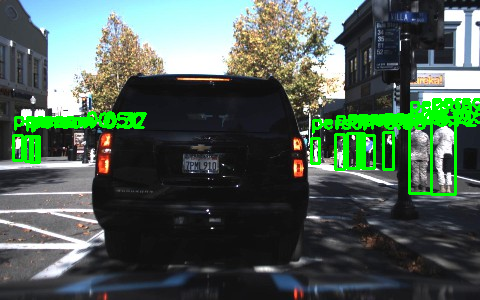

In [9]:
for i in range(4):
    row = peds_df.iloc[i]
    image_path = f"{data_path}/images/{row['frame']}"
    print(f"Pedestrian Detection - Image {i+1}")
    detect_peds(image_path)

# Trying with self traffic images

In [10]:
from google.colab import files
uploaded = files.upload()

for x in uploaded.keys():
    print(f"Detecting in: {x}")
    detect_peds(x)

Output hidden; open in https://colab.research.google.com to view.